# Assignment 1

Deadline: 19.03.2025, 12:00 CET

<Eric Björfors, 24-750-358, ericwilhelmsigvard.bjoerfors@uzh.ch>
<Miquel Muñoz García-Ramos, 24-750-911, miquel.munozgarcia-ramos@uzh.ch>
<Justus Krecker, 24-750-739, Karljustus.krecker@uzh.ch>
<Dani Nijboer, 24-750-960, danijariepeter.nijboer@uzh.ch>
<Valentino Orselli, 24-751-018, valentino.orselli@uzh.ch>


In [175]:
# Import standard libraries
import os
import sys
import timeit # To compute runtimes
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
#src_path = os.path.join(project_root, 'qpmwp-course\\src')
src_path = os.path.join(project_root, 'qpmwp-course', 'src')
sys.path.append(project_root)
sys.path.append(src_path)
print("Current working directory:", os.getcwd())


from optimization.constraints import Constraints
from estimation.covariance import Covariance, CovarianceSpecification
from estimation.expected_return import ExpectedReturn, ExpectedReturnSpecification

from optimization.optimization import Optimization, Objective, MeanVariance
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS

Current working directory: /Users/ericbjorfors/Library/Mobile Documents/com~apple~CloudDocs/Quant Portfolio Management/qpmwp-course/assignments


## 1. Solver Horse Race

### 1.a)
(3 points)

Generate a Multivariate-Normal random dataset of dimension TxN, T=1000, N=100, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [176]:

# Set the dimensions
T = 1000  # Number of time periods
N = 100   # Number of assets
np.random.seed(42) #for reproducibility

#Generate a random mean vector and covariance matrix for the multivariate normal distribution
mean = np.random.normal(0.001,0.01,size=N)
A = np.random.randn(N,N)
cov = np.dot(A, A.T)

# Generate the Multivariate-Normal random dataset
data = np.random.multivariate_normal(mean,cov,size=T)

# Convert the dataset to a DataFrame
df = pd.DataFrame(data, columns=[f'Asset_{i+1}' for i in range(N)])


# Compute the vector of expected returns (mean returns) from df
expected_return_model = ExpectedReturn(spec=ExpectedReturnSpecification(method='geometric'))
expected_return_model.estimate(df, inplace = True)

q = expected_return_model.estimate(df, inplace = False)

# Compute the covariance matrix from df
covariance_model = Covariance(spec=CovarianceSpecification(method='pearson'))
covariance_model.estimate(df, inplace=True)

P = covariance_model.estimate(df, inplace=False)



# Display the results
print("Vector of expected returns (q):")
print(expected_return_model)
print(q)

print("\nCovariance matrix (P):")
print(covariance_model)
print(P)

Vector of expected returns (q):
Asset_1      4.104860
Asset_2      4.940917
Asset_3      4.106976
Asset_4      5.093468
Asset_5      3.993685
               ...   
Asset_96     5.269183
Asset_97     4.483924
Asset_98     4.479404
Asset_99     4.820661
Asset_100    4.476224
Length: 100, dtype: float64

Covariance matrix (P):
             Asset_1     Asset_2    Asset_3     Asset_4    Asset_5    Asset_6  \
Asset_1    86.559704   -2.505917  -0.109114   17.285617 -11.267312  10.549684   
Asset_2    -2.505917  118.549055   0.387474  -12.660747 -13.659994 -17.810305   
Asset_3    -0.109114    0.387474  76.781961   15.658849   2.052665   3.365454   
Asset_4    17.285617  -12.660747  15.658849  102.525347 -10.422440   3.743264   
Asset_5   -11.267312  -13.659994   2.052665  -10.422440  85.577967  -9.204736   
...              ...         ...        ...         ...        ...        ...   
Asset_96  -19.707984   -7.206096  -9.046881    3.343347   1.984323  14.444541   
Asset_97   18.343781   -9.

/Users/ericbjorfors/opt/anaconda3/envs/qpsolve_env/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the data created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 30 assets is <= 0.3, the sum of assets 31 to 60 is <= 0.4 and the sum of assets 61 to 100 is <= 0.5

In [177]:
# Instantiate the Constraints class
constraints = Constraints(ids = df.columns.tolist())

# Add budget constraint
constraints.add_budget(rhs=1, sense='=')

# Add box constraints (i.e., lower and upper bounds)
constraints.add_box(lower=0.0, upper=0.2)

# Add linear constraints
G = pd.DataFrame(np.zeros((3,N)), columns = constraints.ids)
G.iloc[0, 0:30] = 1
G.iloc[1, 30:60] = 1 
G.iloc[2, 60:100] = 1
h = pd.Series([0.3, 0.4, 0.5])
constraints.add_linear(G=G, sense='<=', rhs=h)

print("\nBudget constraint:")
print(constraints.budget)

print("\nBox constraints (bounds):")
print(constraints.box)

print("\nGroup constraints (linear inequalities):")
print(constraints.linear)


Budget constraint:
{'Amat': Asset_1      1.0
Asset_2      1.0
Asset_3      1.0
Asset_4      1.0
Asset_5      1.0
            ... 
Asset_96     1.0
Asset_97     1.0
Asset_98     1.0
Asset_99     1.0
Asset_100    1.0
Length: 100, dtype: float64, 'sense': '=', 'rhs': 1}

Box constraints (bounds):
{'box_type': 'LongOnly', 'lower': Asset_1      0.0
Asset_2      0.0
Asset_3      0.0
Asset_4      0.0
Asset_5      0.0
            ... 
Asset_96     0.0
Asset_97     0.0
Asset_98     0.0
Asset_99     0.0
Asset_100    0.0
Length: 100, dtype: float64, 'upper': Asset_1      0.2
Asset_2      0.2
Asset_3      0.2
Asset_4      0.2
Asset_5      0.2
            ... 
Asset_96     0.2
Asset_97     0.2
Asset_98     0.2
Asset_99     0.2
Asset_100    0.2
Length: 100, dtype: float64}

Group constraints (linear inequalities):
{'G':    Asset_1  Asset_2  Asset_3  Asset_4  Asset_5  Asset_6  Asset_7  Asset_8  \
0      1.0      1.0      1.0      1.0      1.0      1.0      1.0      1.0   
1      0.0      0.0      0.

### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constarints fulfilled? Extract primal resisduals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers that failed for some reason (e.g., unable to install the package or solvers throws an error during execution). 




In [178]:
# Extract the constraints in the format required by the solver
GhAb = constraints.to_GhAb()

risk_aversion = 1

# Loop over solvers, instantiate the quadratic program, solve it and store the results
metrics = ["Solution Found", "Objective Value", "Primal Residual", "Dual Residual", "Duality Gap", "Runtime"]
solver_df = pd.DataFrame(index=metrics)

for solver_method in USABLE_SOLVERS:
    qp = QuadraticProgram(
        P = covariance_model.matrix.to_numpy() * risk_aversion,
        q = expected_return_model.vector.to_numpy() * -1,
        G = GhAb['G'],
        h = GhAb['h'],
        A = GhAb['A'],
        b = GhAb['b'],
        lb = constraints.box['lower'].to_numpy(),
        ub = constraints.box['upper'].to_numpy(),
        solver = solver_method,
    )
    runtime = timeit.timeit("qp.solve()", globals=globals(), number=10) / 10
    qp.solve()
    solution = qp.results.get('solution')
    solver_df[solver_method] = [solution.found,qp.objective_value(),solution.primal_residual(),solution.dual_residual(),solution.duality_gap()[0], runtime]
print(solution)


Solution(problem=<qpsolvers.problem.Problem object at 0x1d9084190>, extras={}, found=True, obj=-4.636710099146512, x=array([ 3.49789523e-02,  2.89587798e-02, -4.51245192e-14,  1.37052847e-02,
        1.38050366e-02,  5.75531912e-03,  1.26595862e-02,  7.83321015e-03,
        1.03298817e-03,  1.22468812e-02, -3.68525795e-15, -1.12032966e-13,
        1.08389912e-13,  5.88234276e-03,  3.53085924e-14,  5.07378257e-03,
        8.64575456e-03,  7.65428989e-14, -7.32219855e-14,  8.92679060e-14,
        3.58376371e-15,  1.76204798e-02,  2.34207618e-02, -5.71857131e-14,
        2.41332593e-02, -3.99560240e-14, -6.05159594e-14,  1.38121279e-02,
        9.80254311e-03,  1.51431539e-02, -1.53414684e-13,  1.20874247e-02,
        1.58696608e-02,  3.78418642e-14,  1.27055323e-02,  3.40832880e-13,
       -9.83304962e-14, -3.22462210e-14,  1.34071014e-02,  2.23857669e-14,
       -1.73577556e-13,  1.57899584e-02, -9.71965840e-14, -1.08570640e-13,
       -1.45232173e-14,  4.96397330e-03,  6.11051011e-03, 

Print and visualize the results

In [179]:
solver_df

,qpalm,highs,osqp,quadprog,cvxopt,daqp
Solution Found,True,True,True,True,True,True
Objective Value,-4.636712,-4.63671,-4.636711,-4.63671,-4.63671,-4.63671
Primal Residual,0.000054,0.0,0.000001,0.0,0.0,0.0
Dual Residual,0.0,0.0,0.000013,0.0,0.0,0.0
Duality Gap,0.000002,0.0,0.0,0.0,0.000001,0.0
Runtime,0.004708,0.006467,0.002916,0.001798,0.024075,0.000792


We can see that all available solvers find the same solution and that daqp is the fastest for this problem.

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


Analytical solution of the MinVariance problem: 
$x^* = \frac{P^{-1} \mathbf{1}}{\mathbf{1}^T P^{-1} \mathbf{1}}$ where P is the covariance matrix



In [180]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance
        
    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        zeros_mean = np.zeros(100) #sets the mean to zero, then the term is excluded when solving numerically
        self.objective = Objective(
            q = zeros_mean,
            P = covmat,
        )
        self.objective.P = covmat

    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            try: 
                #Analytical Solution x* = (P^-1) * 1 /( 1^T * P^-1 * 1)
                P_inv = np.linalg.inv(self.objective.P)
                ones = np.ones((P_inv.shape[0], 1))
                x_star = (P_inv@ones) / (ones.T @ P_inv @ ones)
                self.results = {'solution': x_star.flatten()}
            except np.linalg.LinAlgError:
                print('Covariance matrix not invertible')
                return super().solve()
        else:
            return super().solve()


# Create a constraints object with just a budget constraint
constraints = Constraints(ids = df.columns.tolist())
constraints.add_budget(rhs=1, sense='=')

# Instantiate the MinVariance class
minVar = MinVariance(
    covariance=covariance_model,
    expected_return = expected_return_model,
    constraints = constraints, 
    solver_name = 'analytical',
)

# Prepare the optimization data and prepare the optimization problem
optimization_data = OptimizationData(return_series=df)
minVar.set_objective(optimization_data=optimization_data)

# Solve the optimization problem and print the weights
minVar.solve()
print(minVar.results)


{'solution': array([ 0.01736643,  0.01691628, -0.05180394,  0.12617048,  0.03194371,
        0.06962437,  0.08356127, -0.07316995, -0.04818202, -0.0167521 ,
       -0.00244758, -0.06210532,  0.04780184,  0.07869466,  0.00975908,
        0.00919831,  0.0020208 ,  0.06412761, -0.06552374,  0.07063187,
       -0.00786073,  0.02007377,  0.08669862, -0.03812878, -0.0197146 ,
       -0.03732954, -0.03028336,  0.0134515 , -0.07641281,  0.02406306,
       -0.04719486,  0.05989137,  0.00952018,  0.06466917, -0.02322232,
        0.1135036 , -0.04929091, -0.02904239,  0.05998751, -0.01646679,
       -0.05862574, -0.02144444, -0.09141893, -0.12114931, -0.02269477,
        0.03848381,  0.12215607,  0.10132561, -0.07284576,  0.02363102,
        0.11842815,  0.02268192, -0.00842507,  0.01231883,  0.04173332,
       -0.03060317, -0.04424759,  0.08867786,  0.02966905,  0.0205065 ,
        0.00800369,  0.05391934, -0.05421574,  0.09985554, -0.08123329,
       -0.06348198,  0.0047009 ,  0.0131633 ,  0.04


Solving the problem numerically as well to compare solutions.

In [181]:
# Instantiate the MinVariance class with a numerical solver
minVar2 = MinVariance(
    covariance=covariance_model,
    expected_return = expected_return_model,
    constraints = constraints,
)

# Prepare the optimization data and prepare the optimization problem
optimization_data = OptimizationData(return_series=df)
minVar2.set_objective(optimization_data=optimization_data)
#print(minVar2.objective.coefficients)

# Solve the optimization problem and print the weights
minVar2.solve()
print(minVar2.results)
print(minVar.results)


{'weights': {'Asset_1': 0.01736643266686295, 'Asset_2': 0.016916278725431548, 'Asset_3': -0.05180394012657124, 'Asset_4': 0.1261704843863684, 'Asset_5': 0.03194371221020926, 'Asset_6': 0.0696243700628608, 'Asset_7': 0.08356127376204403, 'Asset_8': -0.07316994919360965, 'Asset_9': -0.04818202131314492, 'Asset_10': -0.016752096431155602, 'Asset_11': -0.0024475754640064687, 'Asset_12': -0.06210532360929581, 'Asset_13': 0.04780183638710841, 'Asset_14': 0.07869465825401867, 'Asset_15': 0.009759076043223805, 'Asset_16': 0.0091983076440727, 'Asset_17': 0.0020208012037640443, 'Asset_18': 0.06412761409563444, 'Asset_19': -0.06552373580305702, 'Asset_20': 0.07063186702110864, 'Asset_21': -0.00786072847568997, 'Asset_22': 0.020073769663577892, 'Asset_23': 0.086698618163605, 'Asset_24': -0.03812877718893735, 'Asset_25': -0.01971460303565528, 'Asset_26': -0.03732954374911985, 'Asset_27': -0.030283361063782915, 'Asset_28': 0.013451497931392371, 'Asset_29': -0.07641281199589776, 'Asset_30': 0.0240630

Results are the same analytically and numerically, showing a correct analytical implentation.

# Comparing weights

<Axes: >

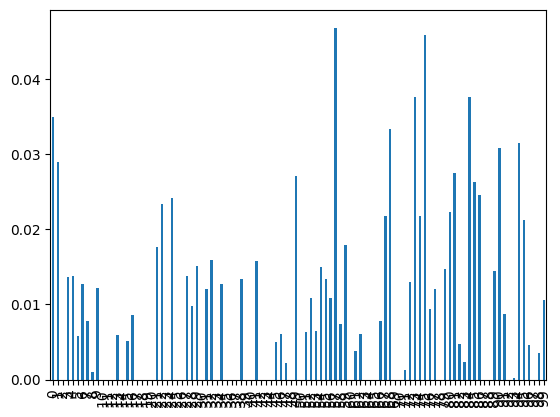

In [183]:
#From Mean-Variance
weights1 = pd.Series(solution.x)
weights1.plot(kind='bar')

<Axes: >

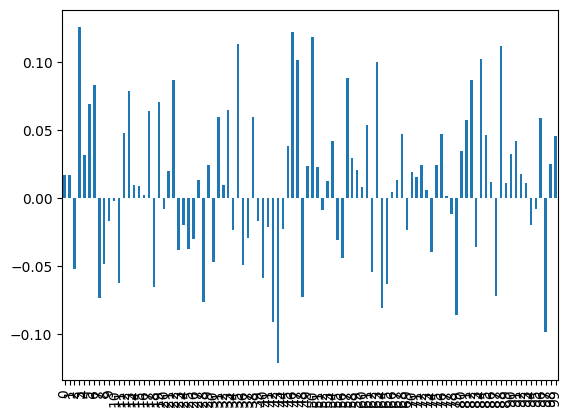

In [184]:
#From Min-Variance
weights = pd.Series(minVar.results['solution'])
weights.plot(kind='bar')

As we can see the difference is that in the Min-Variance problem we are allowed to take negative positions in assets.